This is our first dynamic programming problem which is the money change problem we saw the first time when we visited greedy algorithm approaches. Now we are going to try our way with it with the newfound idea of dynamic programming.  In general the procedure is as follows

1. Check if the the problem has "overlapping subproblems" and an "optimal substructure".
2. Solve the most basic subproblems.
3. Find a way to put the subproblem solutions together to form solutions to new subproblems.
4. Write the algorithm (the step-by-step procedure).
5. Implement the algorithm (test if it works).

The fibonacci problem is often used to showcase the concept of dynamic programming. The equation to solve for the fibonacci problem for some integer $n$ is $F(n) = F(n-1) + F(n-2)$.  

There are overlapping subproblems since the calculation of any n'th fibonacci number is the combination of the 5th and 4th Fibonacci number 8 = 5 + 3. This means we can break down the problem into subproblems. 

The **optimal substructure** means that we can combine solutions to subproblems to form a solution. When we begin we can solve the most basic subproblems which is a good place to start. The most basic solutions are for the integers 0,1,2 and so on. For example we know that $F(0) = 0$ and $F(1), F(2) = 1$. 

To form the $F(3)$ we simply add the two previous calculations $F(3) = F(3-1) + F(3-2)$ for which we know are both 1 so the solution to $F(3) = 2$. 

So let's design the algorithm. First we check if the integer is 0 or 1 for which we know the solution exactly and we can return it immediately and for these there is no calculation needed.

Next we initialize a list object with every element as *None* for the length of the integer + 1. We set the first two entries to 0 and 1 so we have access to them when we want to calculate for the series up until integer. 

A technique used in dynamic programming is **memoization** where we store the solutions to the subproblems we solve. Alternatively we might also use **tabulation** which is what we do here where we store solutions in an array starting with the most basic subproblems. Tabulation is not recursive but starts bottom-up as we built up by solving the most basic subproblems and then progress as the next subproblems rely on these previous solutions. 

The difference between memoization and tabulation can further be understood below. 

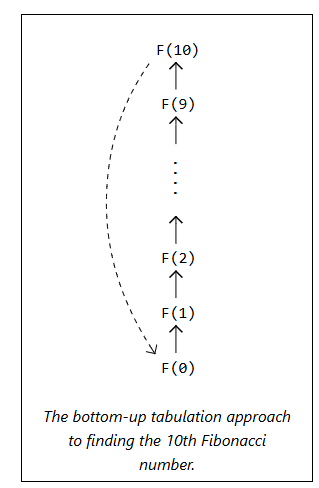

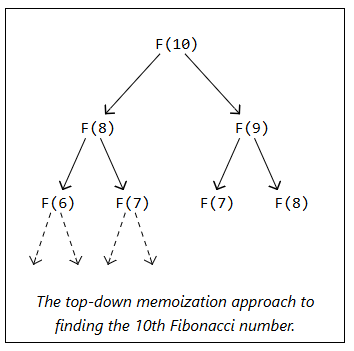

In [6]:
def fibonacci(integer):
    if integer == 0:
        return 0
    if integer == 1:
        return 1
    
    F = [None] * (integer+1)
    F[0] = 0
    F[1] = 1

    for index in range(2, integer + 1):
        F[index] = F[index - 1] + F[index - 2]
    
    return F[integer]


We are now ready to move on to some of the exercises that has is presented for this weeks on dynamic programming. 

In [40]:
def money_change_again(coin):
    denominations = [1,3,4]
    change_left = coin
    num_coins = 0
    while change_left > 0:
        if change_left < denominations[1]:
            num_coins = num_coins + 1
            change_left = change_left - 1
        elif change_left < denominations[2]:
            num_coins = num_coins + 1
            change_left = change_left - 3
        else:
            num_coins = num_coins + 1
            change_left = change_left - 4

    return num_coins

In [41]:
money_change_again(5)

2

Find the minimum number of operations needed to get a postiive integer n from 1 by using only three operations: add 1, multiply by 2 and multiply by 3. 

In [46]:
def primitive_calculator(n):
    num_operations = 0
    start = 1
    operations = []
    operations.append(start)
    while start < n:
        if start * 3 < n:
            start = start * 3
            operations.append(start)
            num_operations += 1
        elif start * 2 < n:
            start = start * 2
            operations.append(start)
            num_operations += 1
        else:
            start = start + 1
            operations.append(start)
            num_operations += 1

    return num_operations, operations

In [48]:
primitive_calculator(1)

(0, [1])

## Edit distance problem

The edit distance problem is about finding the minimum number of single-symbol insertions, deletions and substitutions to transform on string to the other. 

For example the two strings short and ports. Here the first word can be transformed into the second by deleting *s*, substituting *h* for *p* and inserting *s*. 

The dynamic program here is to 

In [123]:
def edit_distance(string_a,string_b):
    edit_distance = 0
    a = 0
    b = 0
    while string_a != string_b:
        print(string_a)
        print(string_b)
        print(f'the index of a is {a}')
        print(f'the index of b is {b}')
        print(f'the current edit distance is {edit_distance}')
        print(f'a+1 is {a+1}')
        if a < len(string_a) and b < len(string_b) and string_a[a] == string_b[b]:
            print('Took equal branch')
            a += 1
            b += 1
        
        # insertions 
        ## insert when the next strin element is equal in b is equal to current a or when we reached
        ## the end of the string_a
        elif a > len(string_a) - 1 or string_a[a] == string_b[b+1]:
            print('Took insertion branch')
            edit_distance += 1 
            if a > len(string_a):
                print("a is longer than string_a so we insert the rest from b")
                string_a = string_a + string_b[b:]
            else:
                string_a = string_a[0:a] + string_b[b] + string_a[a:]

        # substitute
        ## substitute when we are still not at the 
        elif (a < len(string_a) - 1 and string_a[a+1] == string_b[b+1]):
            if (a < len(string_a) - 1 and string_a[a+1] == string_b[b+1]):
                edit_distance += 1
                string_a = string_a[0:a] + string_a[a:].replace(string_a[a], string_b[b])
        
        elif (a + 1) > len(string_a)-1:
            edit_distance += 1
            string_a = string_a[0:a] + string_a[a:].replace(string_a[a], string_b[b])
        # delete 
        elif a < (len(string_a) -1 ) and b < (len(string_b) - 1) and string_a[a+1] != string_b[b+1]:
            print('Took deletion branch')
            edit_distance += 1
            string_a = string_a[1:] 
        

    return edit_distance

In [ ]:
edit_distance('short', 'ports')

Another problems is the longest common subsequence of two sequences. In the problem statement file there is an example of what that really means

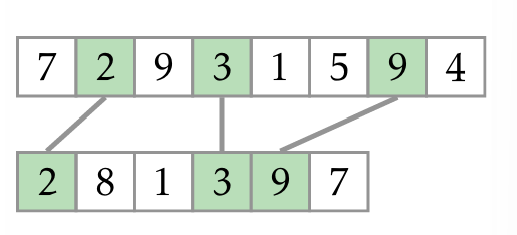

Here it shows that the longest common subsequence is a common subsequence of the maximal length among all subsequences. It's a problem that has application is areas such as computer science and bio. 

Example 

<pre> 2 7 5 </pre>
<pre> 2 5 </pre>

Output 
<pre> (2,5) </pre>

Therefore length of longest common subsequence is 2

In [ ]:
def longest_common_subsequence(sequence_a, sequence_b):
    current_subsequence = 0
    max_subsequence = 0
    i = 0
    j = 0
    k = 0
    for i in range(0, len(sequence_a)):
        for j in range(i+1, len(sequence_a)):
            
    
    while i < len(sequence_a):
        while j <= len(sequence_b)-1:
            if sequence_a[k] == sequence_b[j]:
                current_subsequence += 1
                k += 1
                j += 1
            j += 1
        j = 0
        k += 1
    max_subsequence = max(max_subsequence, current_subsequence)
        
    return max_subsequence

In [11]:
longest_common_subsequence([7,2,9,3,1,5,9,4], [2,8,1,3,9,7])

0
1
3
4
5
5
5
5


5